[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrainardLab/PythonTeachingCode/blob/main/notebooks/CityPopulationDistribution.ipynb)

_Run this notebook in the browser — no install needed._

# City size distribution

Populations of US places (1,000+ residents), from
[GeoNames](https://www.geonames.org/). Raw city sizes are **not**
normal -- not even close -- and this notebook shows that in plain
numbers first. Then we take `log10(population)` and look again: on a
log scale the bulk of the distribution is roughly bell-shaped
(city sizes are approximately *lognormal*).

In [1]:
# --- Make dist_tools.py importable ---------------------------------------
# Locally it sits next to this notebook. On Colab we grab it from GitHub.
import os, urllib.request
if not os.path.exists("dist_tools.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/BrainardLab/PythonTeachingCode"
        "/main/notebooks/dist_tools.py",
        "dist_tools.py",
    )

# Optional: pick up edits to dist_tools.py without restarting the kernel.
# Skipped silently where the autoreload extension is unavailable (e.g. the
# Python 3.13 build currently on Google Colab).
try:
    _ip = get_ipython()
    _ip.run_line_magic("load_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")
except Exception:
    pass

import numpy as np
import pandas as pd
import dist_tools as dt

In [2]:
import io, urllib.request, zipfile

# cities1000.zip is ~11 MB. Swap in cities15000.zip for a smaller,
# faster download (fewer, larger places).
name = "cities1000"
req = urllib.request.Request(
    f"https://download.geonames.org/export/dump/{name}.zip",
    headers={"User-Agent": "Mozilla/5.0"})
blob = urllib.request.urlopen(req, timeout=120).read()
txt = zipfile.ZipFile(io.BytesIO(blob)).read(f"{name}.txt").decode("utf-8")

cols = ["geonameid", "name", "asciiname", "altnames", "lat", "lon",
        "fclass", "fcode", "country", "cc2", "admin1", "admin2",
        "admin3", "admin4", "population", "elevation", "dem", "tz", "moddate"]
cities = pd.read_csv(io.StringIO(txt), sep="\t", header=None,
                     names=cols, low_memory=False)

us = cities[(cities.country == "US") & (cities.population > 0)]
pop = (us.set_index("name")["population"]
         .sort_values(ascending=False)
         .astype(float))

SOURCE = f"GeoNames {name} (populated places, US only)"

city_raw = dt.Distribution(
    values=pop,
    quantity="US city population",
    unit="people",
    noun="cities",
    source=SOURCE,
    value_fmt="{:,.0f}",
)

city_log = dt.Distribution(
    values=np.log10(pop),
    quantity="US city population, log10",
    unit="log10 people",
    noun="cities",
    source=SOURCE,
    bin_width=0.1,
    value_fmt="{:.2f}",
)

### Raw city sizes (straight numbers)

Source:  GeoNames cities1000 (populated places, US only)
Cities included:  17,327
Range:   18 to 8,804,190 people
Mean:    15,906 people
Std dev (1 sigma):  96,642 people

          window | normal predicts |    actual cities
-----------------------------------------------------
  beyond 1 sigma  |         5498.04 |              296
  beyond 2 sigma  |          788.38 |              122
  beyond 3 sigma  |           46.78 |               71
  beyond 4 sigma  |            1.10 |               55
  beyond 5 sigma  |            0.01 |               42

Smallest: 18 people  (-0.2 sigma)  [Brewster]
Largest:  8,804,190 people  (+90.9 sigma)  [New York City]
Skewness (0 = symmetric):      +53.30
Excess kurtosis (0 = normal):  +4217.22


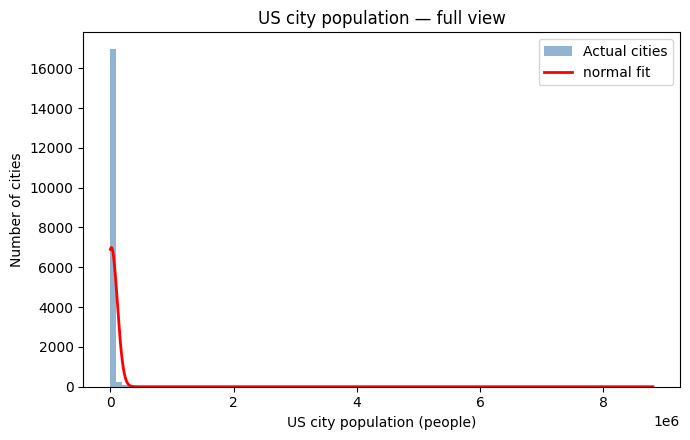

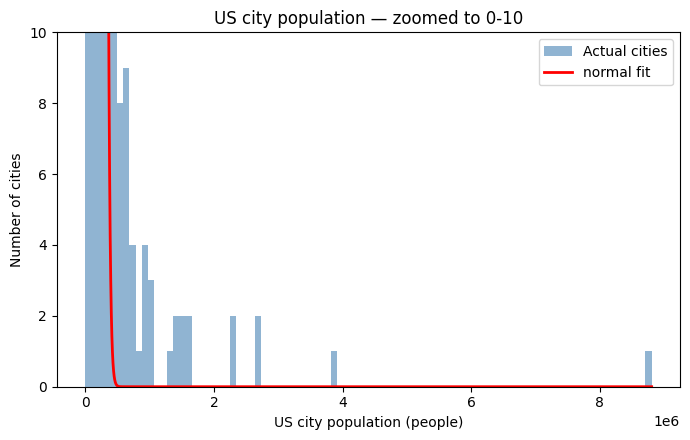

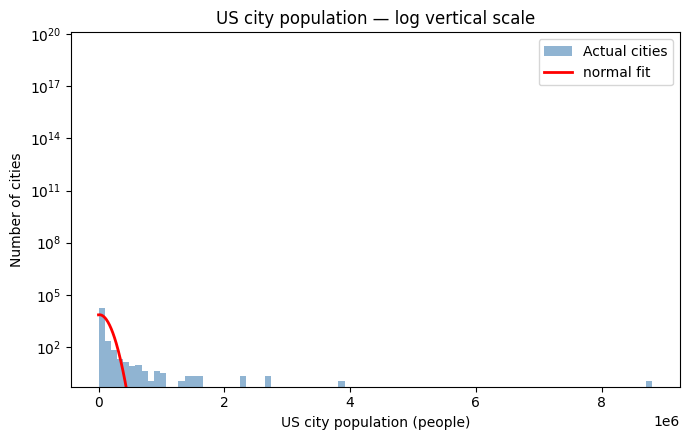

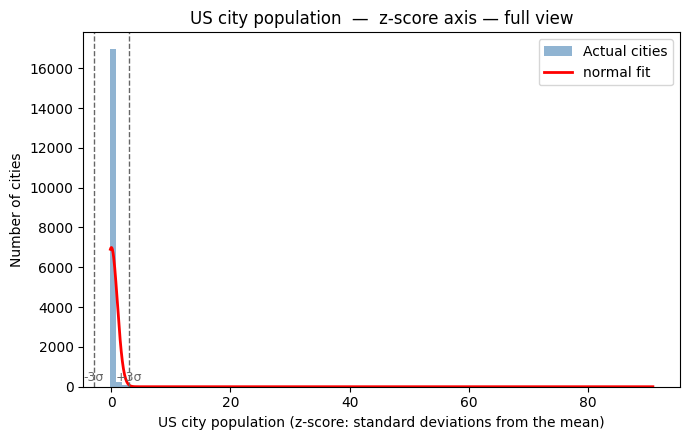

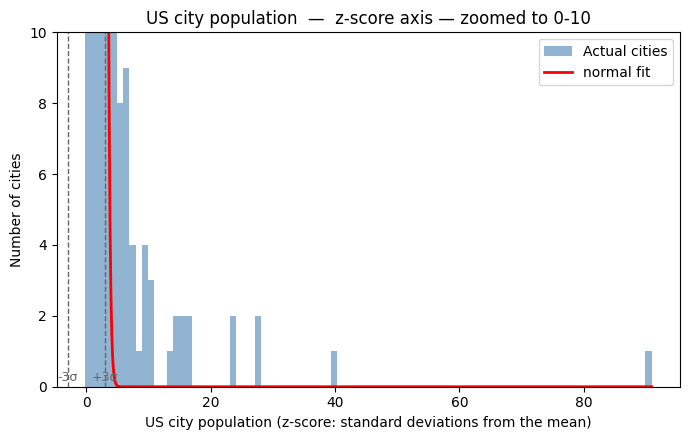

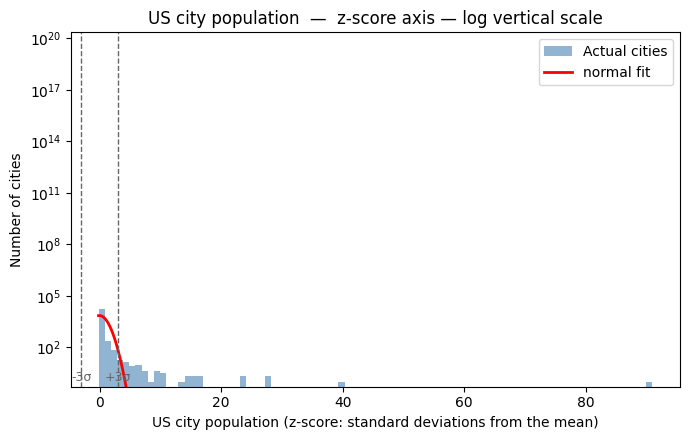

In [3]:
dt.analyze(city_raw)

### The same data, log10 of population

Source:  GeoNames cities1000 (populated places, US only)
Cities included:  17,327
Range:   1.26 to 6.94 log10 people
Mean:    3.70 log10 people
Std dev (1 sigma):  0.56 log10 people

          window | normal predicts |    actual cities
-----------------------------------------------------
  beyond 1 sigma  |         5498.04 |            5,461
  beyond 2 sigma  |          788.38 |              792
  beyond 3 sigma  |           46.78 |              126
  beyond 4 sigma  |            1.10 |               24
  beyond 5 sigma  |            0.01 |                2

Smallest: 1.26 log10 people  (-4.4 sigma)  [Brewster]
Largest:  6.94 log10 people  (+5.8 sigma)  [New York City]
Skewness (0 = symmetric):      +0.73
Excess kurtosis (0 = normal):  +0.69


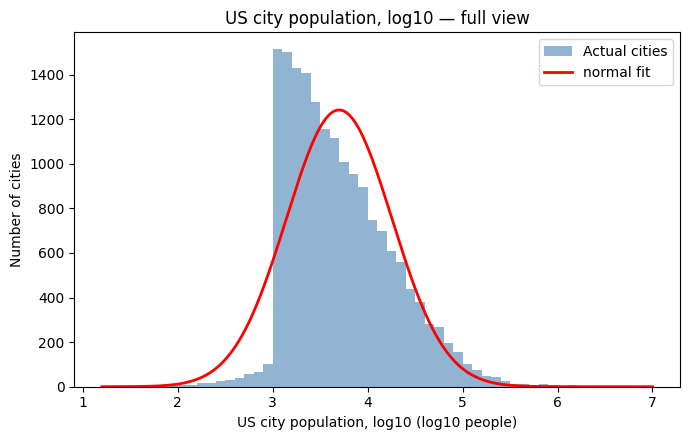

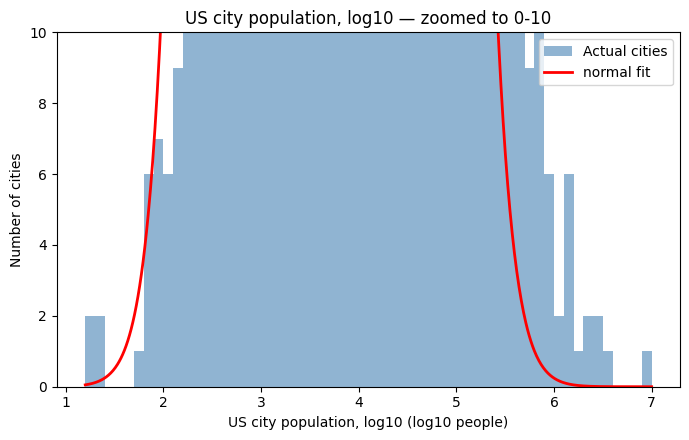

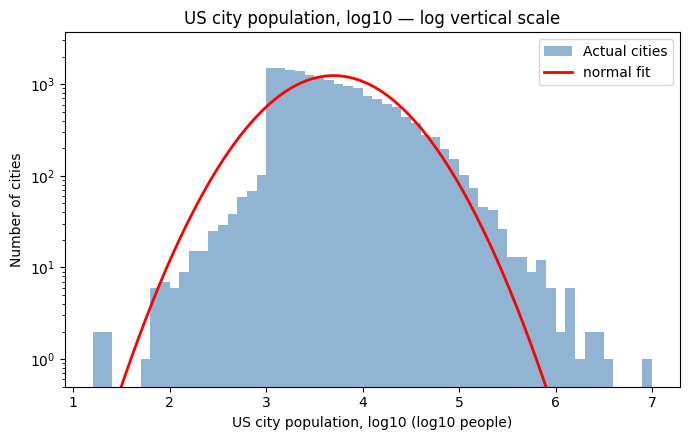

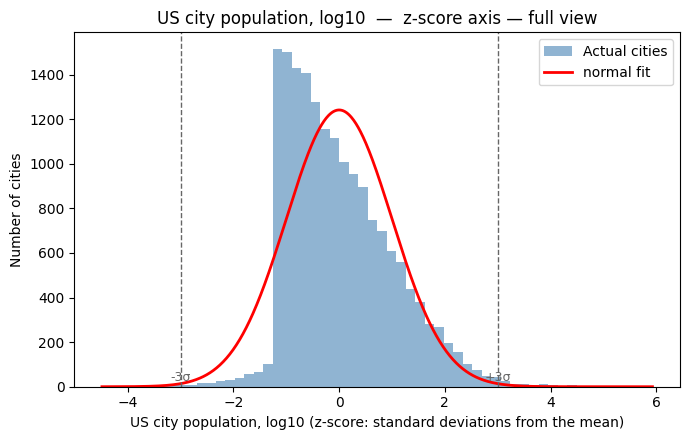

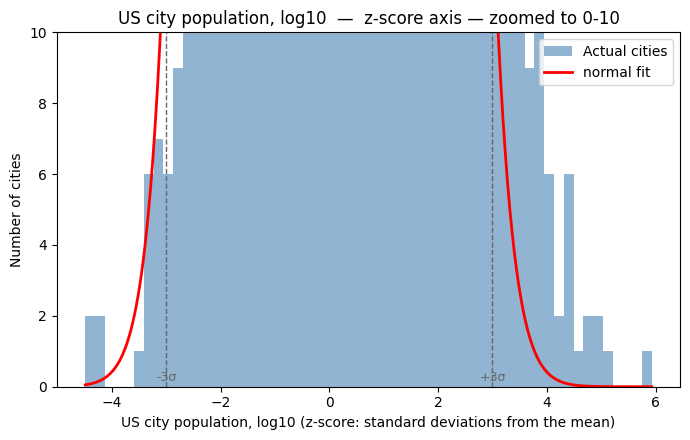

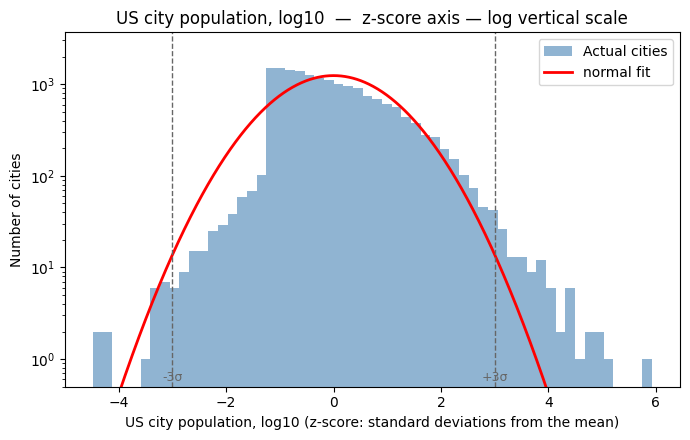

In [4]:
dt.analyze(city_log)

## What to notice

- **Raw:** almost every city sits in the first bar and a thin tail
  stretches out for millions of people. The normal fit is meaningless --
  its standard deviation is set by a few huge cities, it puts the bulk
  of its probability on negative populations, and skew and kurtosis are
  enormous.
- **log10:** the histogram is now roughly bell-shaped and the normal
  fit is vastly better -- counts within 1 and 2 sigma nearly match the
  normal prediction. So population is closer to *lognormal* than
  normal.
- It is not a perfect bell: the data is censored below 1,000 (note the
  cliff at log10 = 3), and the upper tail is still a little heavy --
  rank-size plots of city populations are famously close to a straight
  line on log-log axes (Zipf's law).